In [ ]:
import pandas as pd
fake_df=pd.read_csv("Fake.csv")
real_df=pd.read_csv("True.csv")
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
fake_df["label"]=0
real_df["label"]=1
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
df=pd.concat([fake_df,real_df], axis=0)
df=df.sample(frac=1).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,FLASHBACK: ‘The Syrian War: What You’re Not Be...,"21st Century Wire says Back in August 2013, Un...",US_News,"December 18, 2016",0
1,NEW YORK TIMES Publishes FAKE Story About Dona...,Here s how fake news works In an effort to cas...,politics,"Jul 10, 2017",0
2,BREAKING: PROTESTER JUMPS ON STAGE…Grabs Trump...,A protester tried to attack Trump today at a r...,politics,"Mar 12, 2016",0
3,Senate Republican tax chief wants dividend ded...,WASHINGTON (Reuters) - The U.S. Senate’s top R...,politicsNews,"September 19, 2017",1
4,WATCH: Bill O’Reilly Just Said The Women’s Ma...,Bill O Reilly can always be trusted to be a to...,News,"January 23, 2017",0


In [ ]:
df.shape

(44898, 5)

In [ ]:
df.head()

,title,text,subject,date,label
0,FLASHBACK: ‘The Syrian War: What You’re Not Be...,"21st Century Wire says Back in August 2013, Un...",US_News,"December 18, 2016",0
1,NEW YORK TIMES Publishes FAKE Story About Dona...,Here s how fake news works In an effort to cas...,politics,"Jul 10, 2017",0
2,BREAKING: PROTESTER JUMPS ON STAGE…Grabs Trump...,A protester tried to attack Trump today at a r...,politics,"Mar 12, 2016",0
3,Senate Republican tax chief wants dividend ded...,WASHINGTON (Reuters) - The U.S. Senate’s top R...,politicsNews,"September 19, 2017",1
4,WATCH: Bill O’Reilly Just Said The Women’s Ma...,Bill O Reilly can always be trusted to be a to...,News,"January 23, 2017",0


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df.duplicated().sum()


np.int64(209)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape


(44689, 5)

In [ ]:
#Uppercase to Lowercase
df["text"]=df["text"].str.lower()
# to see one row
df["text"].iloc[0]

'21st century wire says back in august 2013, united nations investigators led by carla del ponte found evidence that alleged chemical weapons attacks by the syrian military were actually staged by us, saudi and qatari-backed jihadist  rebels.  by definition, this was a false flag attack. regardless of the facts, western media and political leaders still decided to blame damascus for the incident. the object of this game was simple: to engineer a virtual  violation  of obama s famous red line, providing the legal pretext, however spurious, for the use of western military force against the nation state of syria   under the guise of the great 21st century western military intervention tactic known as the  responsibility to protect  (r2p). this video was uploaded by storm clouds gathering on sept 3, 2013, and it demonstrated how when the entire mainstream media is going one way   pushing a fraudulent event for the purposes of generating a new war   alternative media outlets were reporting 

In [ ]:
#removing urls using regex
import re
def remove_urls(text):
  return re.sub(r"http\S+|www\S+","",text)
df["text"] =df["text"].apply(remove_urls)
df["text"].iloc[0]

'21st century wire says back in august 2013, united nations investigators led by carla del ponte found evidence that alleged chemical weapons attacks by the syrian military were actually staged by us, saudi and qatari-backed jihadist  rebels.  by definition, this was a false flag attack. regardless of the facts, western media and political leaders still decided to blame damascus for the incident. the object of this game was simple: to engineer a virtual  violation  of obama s famous red line, providing the legal pretext, however spurious, for the use of western military force against the nation state of syria   under the guise of the great 21st century western military intervention tactic known as the  responsibility to protect  (r2p). this video was uploaded by storm clouds gathering on sept 3, 2013, and it demonstrated how when the entire mainstream media is going one way   pushing a fraudulent event for the purposes of generating a new war   alternative media outlets were reporting 

In [ ]:
#Removing html tags
def remove_html_tags(text):
  return re.sub(r"<.*?>","",text)
df["text"]=df["text"].apply(remove_html_tags)
df["text"].iloc[0]


'21st century wire says back in august 2013, united nations investigators led by carla del ponte found evidence that alleged chemical weapons attacks by the syrian military were actually staged by us, saudi and qatari-backed jihadist  rebels.  by definition, this was a false flag attack. regardless of the facts, western media and political leaders still decided to blame damascus for the incident. the object of this game was simple: to engineer a virtual  violation  of obama s famous red line, providing the legal pretext, however spurious, for the use of western military force against the nation state of syria   under the guise of the great 21st century western military intervention tactic known as the  responsibility to protect  (r2p). this video was uploaded by storm clouds gathering on sept 3, 2013, and it demonstrated how when the entire mainstream media is going one way   pushing a fraudulent event for the purposes of generating a new war   alternative media outlets were reporting 

In [ ]:
# emoji removal
def remove_emojis(text):
    # this pattern defines RANGES of unicode characters that represent emojis
    # unicode is just a big numbered list where every character (letters, symbols, emojis) has a unique number
    # emojis live in specific number ranges, so we can target just those ranges
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons (like 😀 😂 😭)
        "\U0001F300-\U0001F5FF"  # symbols & pictographs (like 🔥 💀)
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub("", text)

df["text"] = df["text"].apply(remove_emojis)

# check again
df["text"].iloc[0]
# not used this function

'washington (reuters) - u.s. republican presidential candidate ted cruz’s campaign is vetting former business executive carly fiorina as a possible vice presidential pick, abc news said on friday. earlier, cruz’s campaign said it had narrowed its running mate options to a short list. fiorina, a former ceo of hewlett packard, dropped out of the presidential race in february. '

In [ ]:
def remove_punctuation(text):
    # [^a-z0-9\s] ka matlab: "koi bhi character jo a-z, 0-9, ya space NA ho"
    # ^ (caret) andar hone ka matlab hai "NOT" - yaani in teeno ke alawa sab kuch
    # aisa har character space se replace ho jaayega
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # multiple spaces ko single space mein convert karo
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
#Removing numbers
def remove_numbers(text):
  return re.sub(r"\d+","",text)
df["text"]=df["text"].apply(remove_numbers)
df["text"].iloc[0]

'st century wire says back in august , united nations investigators led by carla del ponte found evidence that alleged chemical weapons attacks by the syrian military were actually staged by us, saudi and qatari-backed jihadist  rebels.  by definition, this was a false flag attack. regardless of the facts, western media and political leaders still decided to blame damascus for the incident. the object of this game was simple: to engineer a virtual  violation  of obama s famous red line, providing the legal pretext, however spurious, for the use of western military force against the nation state of syria   under the guise of the great st century western military intervention tactic known as the  responsibility to protect  (rp). this video was uploaded by storm clouds gathering on sept , , and it demonstrated how when the entire mainstream media is going one way   pushing a fraudulent event for the purposes of generating a new war   alternative media outlets were reporting the truth. his

In [ ]:
# Removing stopwords
import nltk #natural language tootkit,a library
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
def remove_stopwords(text):
  words=text.split()
  filtered_words=[word for word in words if word not in stop_words]
  return " ".join(filtered_words)
df["text"]=df["text"].apply(remove_stopwords)
df["text"].iloc[0]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'st century wire says back august , united nations investigators led carla del ponte found evidence alleged chemical weapons attacks syrian military actually staged us, saudi qatari-backed jihadist rebels. definition, false flag attack. regardless facts, western media political leaders still decided blame damascus incident. object game simple: engineer virtual violation obama famous red line, providing legal pretext, however spurious, use western military force nation state syria guise great st century western military intervention tactic known responsibility protect (rp). video uploaded storm clouds gathering sept , , demonstrated entire mainstream media going one way pushing fraudulent event purposes generating new war alternative media outlets reporting truth. history side alternative media, likes cnn, abc, nbc, bbc al jazeera. week everyone west thought us-led military action syria fait accompli. thanks brief wave sanity swept british parliament, us could proceed forward without ap

In [ ]:
#tokenization
from nltk.tokenize import word_tokenize
nltk.download('punkt') #punkt pretrained model to seperate words corectly
def tokenize_text(text):
  return word_tokenize(text)
df["tokens"]=df["text"].apply(tokenize_text)
df["tokens"].iloc[0]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['st',
 'century',
 'wire',
 'says',
 'back',
 'august',
 ',',
 'united',
 'nations',
 'investigators',
 'led',
 'carla',
 'del',
 'ponte',
 'found',
 'evidence',
 'alleged',
 'chemical',
 'weapons',
 'attacks',
 'syrian',
 'military',
 'actually',
 'staged',
 'us',
 ',',
 'saudi',
 'qatari-backed',
 'jihadist',
 'rebels',
 '.',
 'definition',
 ',',
 'false',
 'flag',
 'attack',
 '.',
 'regardless',
 'facts',
 ',',
 'western',
 'media',
 'political',
 'leaders',
 'still',
 'decided',
 'blame',
 'damascus',
 'incident',
 '.',
 'object',
 'game',
 'simple',
 ':',
 'engineer',
 'virtual',
 'violation',
 'obama',
 'famous',
 'red',
 'line',
 ',',
 'providing',
 'legal',
 'pretext',
 ',',
 'however',
 'spurious',
 ',',
 'use',
 'western',
 'military',
 'force',
 'nation',
 'state',
 'syria',
 'guise',
 'great',
 'st',
 'century',
 'western',
 'military',
 'intervention',
 'tactic',
 'known',
 'responsibility',
 'protect',
 '(',
 'rp',
 ')',
 '.',
 'video',
 'uploaded',
 'storm',
 'clouds',


In [ ]:
#lookup error fixed
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # newer nltk versions need this additional resource for tokenization

from nltk.tokenize import word_tokenize

def tokenize_text(text):
    return word_tokenize(text)

df["tokens"] = df["text"].apply(tokenize_text)
df["tokens"].iloc[0]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['washington',
 '(',
 'reuters',
 ')',
 '-',
 'u.s.',
 'republican',
 'presidential',
 'candidate',
 'ted',
 'cruz',
 '’',
 's',
 'campaign',
 'vetting',
 'former',
 'business',
 'executive',
 'carly',
 'fiorina',
 'possible',
 'vice',
 'presidential',
 'pick',
 ',',
 'abc',
 'news',
 'said',
 'friday',
 '.',
 'earlier',
 ',',
 'cruz',
 '’',
 's',
 'campaign',
 'said',
 'narrowed',
 'running',
 'mate',
 'options',
 'short',
 'list',
 '.',
 'fiorina',
 ',',
 'former',
 'ceo',
 'hewlett',
 'packard',
 ',',
 'dropped',
 'presidential',
 'race',
 'february',
 '.']

In [ ]:
#lemmatization
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')  # wordnet ek dictionary-type database hai jo lemmatizer use karta hai root words dhundhne ke liye

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    # har token (word) ko uske root form mein convert karte hain
    return [lemmatizer.lemmatize(word) for word in tokens]

df["tokens"] = df["tokens"].apply(lemmatize_tokens)

# check karte hain ek example
df["tokens"].iloc[0]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['st',
 'century',
 'wire',
 'say',
 'back',
 'august',
 ',',
 'united',
 'nation',
 'investigator',
 'led',
 'carla',
 'del',
 'ponte',
 'found',
 'evidence',
 'alleged',
 'chemical',
 'weapon',
 'attack',
 'syrian',
 'military',
 'actually',
 'staged',
 'u',
 ',',
 'saudi',
 'qatari-backed',
 'jihadist',
 'rebel',
 '.',
 'definition',
 ',',
 'false',
 'flag',
 'attack',
 '.',
 'regardless',
 'fact',
 ',',
 'western',
 'medium',
 'political',
 'leader',
 'still',
 'decided',
 'blame',
 'damascus',
 'incident',
 '.',
 'object',
 'game',
 'simple',
 ':',
 'engineer',
 'virtual',
 'violation',
 'obama',
 'famous',
 'red',
 'line',
 ',',
 'providing',
 'legal',
 'pretext',
 ',',
 'however',
 'spurious',
 ',',
 'use',
 'western',
 'military',
 'force',
 'nation',
 'state',
 'syria',
 'guise',
 'great',
 'st',
 'century',
 'western',
 'military',
 'intervention',
 'tactic',
 'known',
 'responsibility',
 'protect',
 '(',
 'rp',
 ')',
 '.',
 'video',
 'uploaded',
 'storm',
 'cloud',
 'gatheri

In [ ]:
# tokens (list of words) ko wapas ek single string mein jodna
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

df["clean_text"].iloc[0]

'st century wire say back august , united nation investigator led carla del ponte found evidence alleged chemical weapon attack syrian military actually staged u , saudi qatari-backed jihadist rebel . definition , false flag attack . regardless fact , western medium political leader still decided blame damascus incident . object game simple : engineer virtual violation obama famous red line , providing legal pretext , however spurious , use western military force nation state syria guise great st century western military intervention tactic known responsibility protect ( rp ) . video uploaded storm cloud gathering sept , , demonstrated entire mainstream medium going one way pushing fraudulent event purpose generating new war alternative medium outlet reporting truth . history side alternative medium , like cnn , abc , nbc , bbc al jazeera . week everyone west thought us-led military action syria fait accompli . thanks brief wave sanity swept british parliament , u could proceed forward

In [ ]:
df["clean_text"].iloc[0]

'st century wire say back august , united nation investigator led carla del ponte found evidence alleged chemical weapon attack syrian military actually staged u , saudi qatari-backed jihadist rebel . definition , false flag attack . regardless fact , western medium political leader still decided blame damascus incident . object game simple : engineer virtual violation obama famous red line , providing legal pretext , however spurious , use western military force nation state syria guise great st century western military intervention tactic known responsibility protect ( rp ) . video uploaded storm cloud gathering sept , , demonstrated entire mainstream medium going one way pushing fraudulent event purpose generating new war alternative medium outlet reporting truth . history side alternative medium , like cnn , abc , nbc , bbc al jazeera . week everyone west thought us-led military action syria fait accompli . thanks brief wave sanity swept british parliament , u could proceed forward

In [ ]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

# Step 1: Load data
fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")

# Step 2: Label
fake_df["label"] = 0
real_df["label"] = 1

# Step 3: Merge + Shuffle
df = pd.concat([fake_df, real_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

# Step 4: Remove duplicates
df.drop_duplicates(inplace=True)

# Step 5: Lowercase
df["text"] = df["text"].str.lower()

# Step 6: Remove URLs
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)
df["text"] = df["text"].apply(remove_urls)

# Step 7: Remove HTML tags
def remove_html_tags(text):
    return re.sub(r"<.*?>", "", text)
df["text"] = df["text"].apply(remove_html_tags)

# Step 8: Remove punctuation (fixed version - removes ANY non-letter/number/space character)
def remove_punctuation(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["text"] = df["text"].apply(remove_punctuation)

# Step 9: Remove numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)
df["text"] = df["text"].apply(remove_numbers)

# Step 10: Remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
df["text"] = df["text"].apply(remove_stopwords)

# Step 11: Tokenization
def tokenize_text(text):
    return word_tokenize(text)
df["tokens"] = df["text"].apply(tokenize_text)

# Step 12: Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]
df["tokens"] = df["tokens"].apply(lemmatize_tokens)

# Step 13: Join tokens back into clean sentence
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

print("Done! Shape:", df.shape)
df["clean_text"].iloc[0]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Done! Shape: (44689, 7)


'beirut reuters lebanese president michel aoun office said saturday saad al hariri phoned outside lebanon resign country prime minister aoun awaited hariri return hear circumstance resignation'

In [ ]:
#df.to_csv("cleaned_news_data.csv", index=False)
# tokens column ko drop karo (list format CSV ke liye problematic hai)
df_to_save = df.drop(columns=["tokens"])

# ab bina tokens column ke save karo
df_to_save.to_csv("cleaned_news_data.csv", index=False)

print("Saved! New shape:", df_to_save.shape)

Saved! New shape: (39805, 6)


In [ ]:
print(df.shape)
print(df.columns.tolist())

(39805, 7)
['title', 'text', 'subject', 'date', 'label', 'tokens', 'clean_text']


In [ ]:
#poori pipeline phirse run
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

# Step 1: Load data (Fake.csv aur True.csv upload hone chahiye Colab mein)
fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")

# Step 2: Label
fake_df["label"] = 0
real_df["label"] = 1

# Step 3: Merge + Shuffle
df = pd.concat([fake_df, real_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

# Step 4: Remove duplicates
df.drop_duplicates(inplace=True)

# Step 5: Lowercase
df["text"] = df["text"].str.lower()

# Step 6: Remove URLs
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)
df["text"] = df["text"].apply(remove_urls)

# Step 7: Remove HTML tags
def remove_html_tags(text):
    return re.sub(r"<.*?>", "", text)
df["text"] = df["text"].apply(remove_html_tags)

# Step 8: Remove punctuation (general fix - removes any non-letter/number/space char)
def remove_punctuation(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["text"] = df["text"].apply(remove_punctuation)

# Step 9: Remove numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)
df["text"] = df["text"].apply(remove_numbers)

# Step 10: Remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
df["text"] = df["text"].apply(remove_stopwords)

# Step 11: Tokenization
def tokenize_text(text):
    return word_tokenize(text)
df["tokens"] = df["text"].apply(tokenize_text)

# Step 12: Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]
df["tokens"] = df["tokens"].apply(lemmatize_tokens)

# Step 13: Join tokens back into clean sentence
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

print("Pipeline done! Shape:", df.shape)

# Step 14: IMPORTANT - drop tokens column before saving (list format breaks CSV)
df_to_save = df.drop(columns=["tokens"])
df_to_save.to_csv("cleaned_news_data.csv", index=False)

print("Saved successfully! Final shape:", df_to_save.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


FileNotFoundError: [Errno 2] No such file or directory: 'Fake.csv'

In [ ]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

# Step 1: Load data (Fake.csv aur True.csv upload hone chahiye Colab mein)
fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")

# Step 2: Label
fake_df["label"] = 0
real_df["label"] = 1

# Step 3: Merge + Shuffle
df = pd.concat([fake_df, real_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

# Step 4: Remove duplicates
df.drop_duplicates(inplace=True)

# Step 5: Lowercase
df["text"] = df["text"].str.lower()

# Step 6: Remove URLs
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)
df["text"] = df["text"].apply(remove_urls)

# Step 7: Remove HTML tags
def remove_html_tags(text):
    return re.sub(r"<.*?>", "", text)
df["text"] = df["text"].apply(remove_html_tags)

# Step 8: Remove punctuation (general fix - removes any non-letter/number/space char)
def remove_punctuation(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["text"] = df["text"].apply(remove_punctuation)

# Step 9: Remove numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)
df["text"] = df["text"].apply(remove_numbers)

# Step 10: Remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
df["text"] = df["text"].apply(remove_stopwords)

# Step 11: Tokenization
def tokenize_text(text):
    return word_tokenize(text)
df["tokens"] = df["text"].apply(tokenize_text)

# Step 12: Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]
df["tokens"] = df["tokens"].apply(lemmatize_tokens)

# Step 13: Join tokens back into clean sentence
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

print("Pipeline done! Shape:", df.shape)

# Step 14: IMPORTANT - drop tokens column before saving (list format breaks CSV)
df_to_save = df.drop(columns=["tokens"])
df_to_save.to_csv("cleaned_news_data.csv", index=False)

print("Saved successfully! Final shape:", df_to_save.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Pipeline done! Shape: (44689, 7)
Saved successfully! Final shape: (44689, 6)


In [ ]:
import pandas as pd
df = pd.read_csv("cleaned_news_data.csv")
print(df.shape)
df.head()

(44689, 6)


,title,text,subject,date,label,clean_text
0,TERROR GROUP PLANS VIOLENCE AGAINST TRUMP SUPP...,call violence left innocent people agree radic...,politics,"Jun 11, 2016",0,call violence left innocent people agree radic...
1,Putin Just Spit In America’s Face And Trump T...,years donald trump built great negotiator grea...,News,"August 10, 2017",0,year donald trump built great negotiator great...
2,MUSLIM ATHLETE Given “Hero’s Welcome” INDICTED...,media cheered democrat senator chuck schumer n...,left-news,"Nov 1, 2017",0,medium cheered democrat senator chuck schumer ...
3,"DAY AFTER DALLAS COPS’ MEMORIAL, Obama Invites...",america elected community agitator idea would ...,left-news,"Jul 13, 2016",0,america elected community agitator idea would ...
4,Russian riot police detain opposition proteste...,st petersburg reuters russian riot police deta...,worldnews,"October 7, 2017",1,st petersburg reuters russian riot police deta...


In [ ]:
# EDA

df["label"].value_counts()

,count
label,
0,23478
1,21211


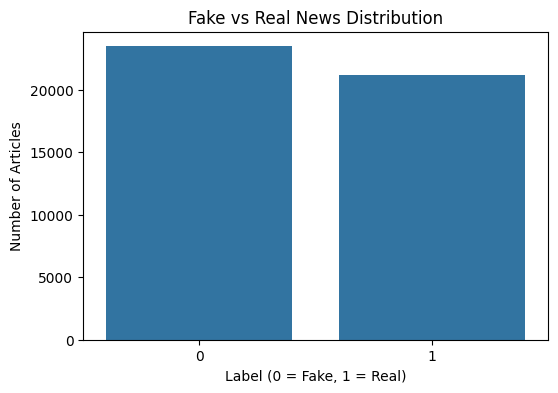

In [ ]:
# using matplotlib for visualization and seaborn
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
# calculating article length
df["text_length"] = df["clean_text"].apply(lambda x: len(str(x).split()))
df.groupby("label")["text_length"].mean()

,text_length
label,
0,237.021893
1,229.073405


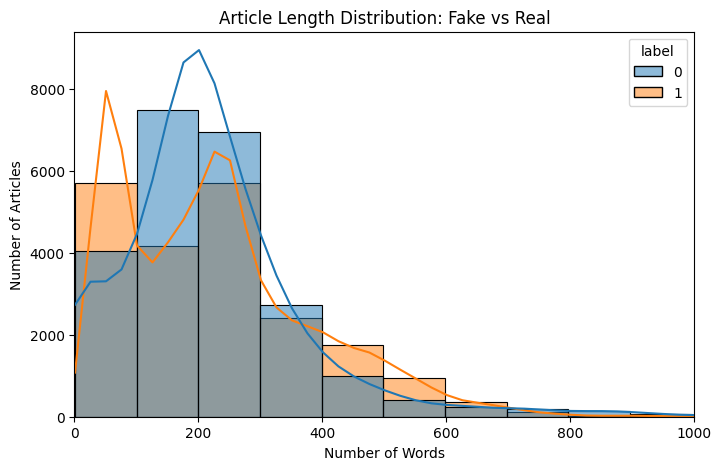

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True)
plt.title("Article Length Distribution: Fake vs Real")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.xlim(0, 1000)  # bahut lambe outlier articles ko chart se temporarily hata rahe hain, taaki main pattern clearly dikhe
plt.show()

In [ ]:
# most common words in real and fake article
from collections import Counter

# NaN values ko empty string mein convert karo,
df["clean_text"] = df["clean_text"].fillna("").astype(str)

# ab safely join kar sakte hain
fake_words = " ".join(df[df["label"]==0]["clean_text"]).split()
real_words = " ".join(df[df["label"]==1]["clean_text"]).split()

fake_word_freq = Counter(fake_words)
real_word_freq = Counter(real_words)

print("Top 20 words in FAKE news:")
print(fake_word_freq.most_common(20))

print("\nTop 20 words in REAL news:")
print(real_word_freq.most_common(20))

Top 20 words in FAKE news:
[('trump', 80019), ('said', 33762), ('president', 28390), ('people', 26676), ('one', 25441), ('u', 24516), ('state', 23665), ('would', 23565), ('clinton', 19857), ('time', 19198), ('year', 19074), ('obama', 18833), ('like', 18667), ('american', 18124), ('donald', 17789), ('republican', 16756), ('say', 15783), ('also', 15420), ('right', 14863), ('news', 14662)]

Top 20 words in REAL news:
[('said', 97867), ('trump', 54119), ('u', 46542), ('state', 37231), ('would', 31249), ('reuters', 28667), ('president', 28416), ('republican', 22866), ('year', 22355), ('government', 19681), ('house', 16877), ('new', 16758), ('also', 15754), ('united', 15368), ('people', 15158), ('party', 15101), ('election', 14603), ('official', 14406), ('told', 14072), ('country', 13972)]


In [ ]:
!pip install wordcloud

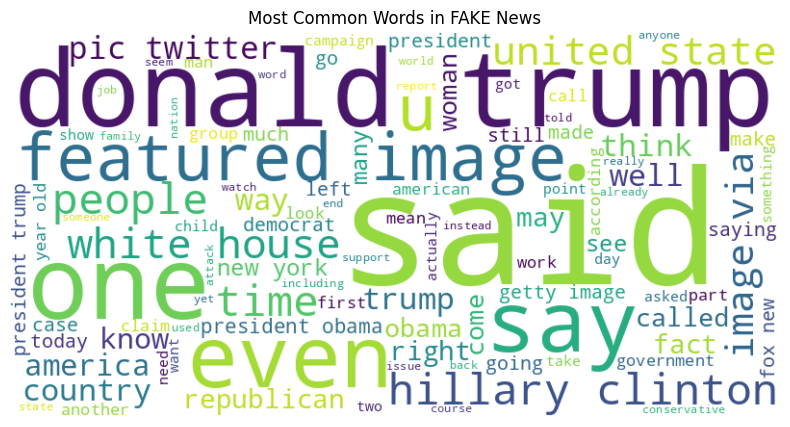

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordCloud ko ek single string chahiye, list nahi, isliye wapas jodte hain
fake_text = " ".join(fake_words)

# WordCloud object
wordcloud_fake = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=100          # sirf top 100 words
).generate(fake_text)

# display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")   # x/y axis numbers hata do, unka koi matlab nahi yahan
plt.title("Most Common Words in FAKE News")
plt.show()

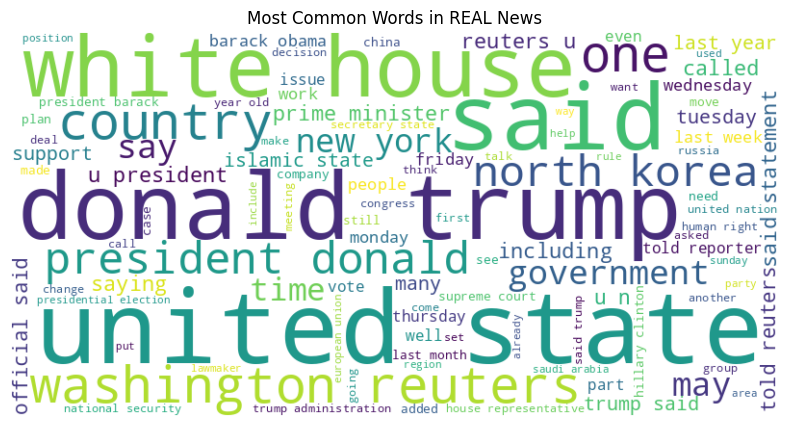

In [ ]:
real_text = " ".join(real_words)

wordcloud_real = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=100
).generate(real_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_real, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in REAL News")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features: sirf top 5000 sabse important words/phrases
# ngram_range=(1,2): unigrams (single words) AUR bigrams (2-word phrases)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))


X = tfidf.fit_transform(df["clean_text"])

# y =  target/label column (0 = fake, 1 = real)
y = df["label"]


print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (44689, 5000)
y shape: (44689,)


In [ ]:
#ml models train
#train/test split
from sklearn.model_selection import train_test_split

# X aur y 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 35751
Testing samples: 8938


In [ ]:
#model train with logistic regression baseline model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# model create
lr_model = LogisticRegression(max_iter=1000)

# training data learn
lr_model.fit(X_train, y_train)

# test data predict
lr_predictions = lr_model.predict(X_test)

# accuracy check
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9884761691653614


In [ ]:
#model 2 train using naive bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.947751174759454


In [ ]:
#model 3 train using decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9975385992392034


In [ ]:
#model 4 train using random forest
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100: 100 alag decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9980980085030208


In [ ]:
#model 5 training using svm
from sklearn.svm import LinearSVC

# LinearSVC
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9954128440366973


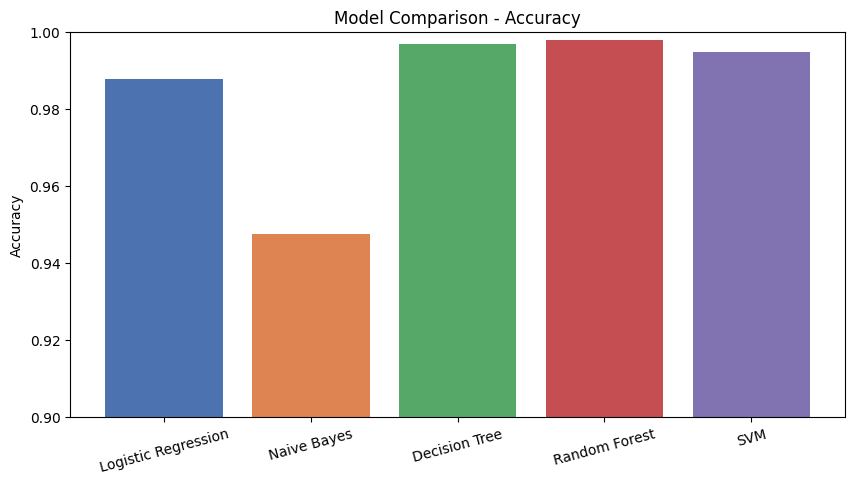

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'SVM']
accuracies = [0.988, 0.9477, 0.997, 0.998, 0.995]

plt.figure(figsize=(10,5))
plt.bar(models, accuracies, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.xticks(rotation=15)
plt.show()

===== Logistic Regression =====
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



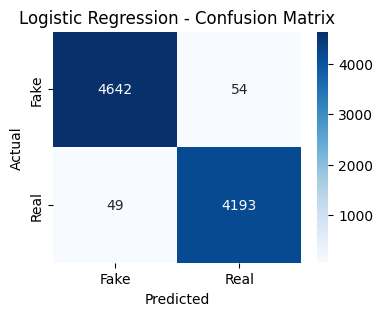

===== Naive Bayes =====
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95      4696
        Real       0.94      0.95      0.95      4242

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938



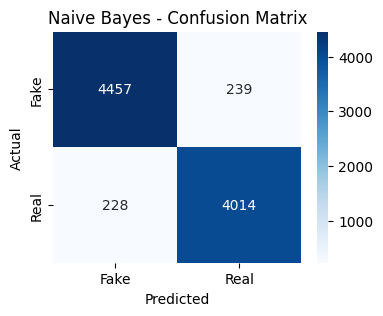

===== Decision Tree =====
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



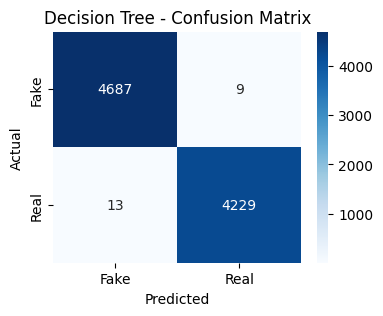

===== Random Forest =====
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



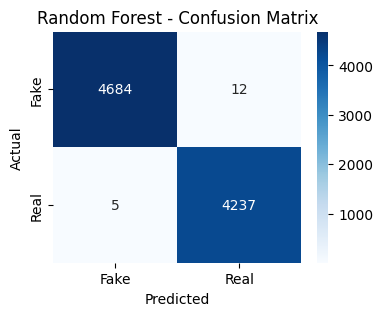

===== SVM =====
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      0.99      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



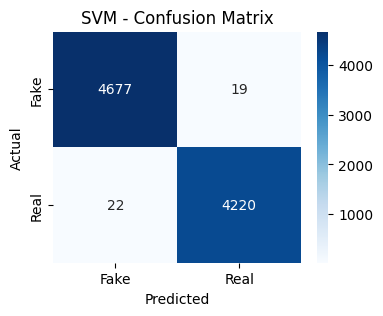

In [ ]:
#model evaluation using confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_test, predictions):
    print(f"===== {model_name} =====")

    # classification_report,precision, recall, f1-score, accuracy
    print(classification_report(y_test, predictions, target_names=["Fake", "Real"]))

    # confusion matrix visualization
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

evaluate_model("Logistic Regression", y_test, lr_predictions)
evaluate_model("Naive Bayes", y_test, nb_predictions)
evaluate_model("Decision Tree", y_test, dt_predictions)
evaluate_model("Random Forest", y_test, rf_predictions)
evaluate_model("SVM", y_test, svm_predictions)


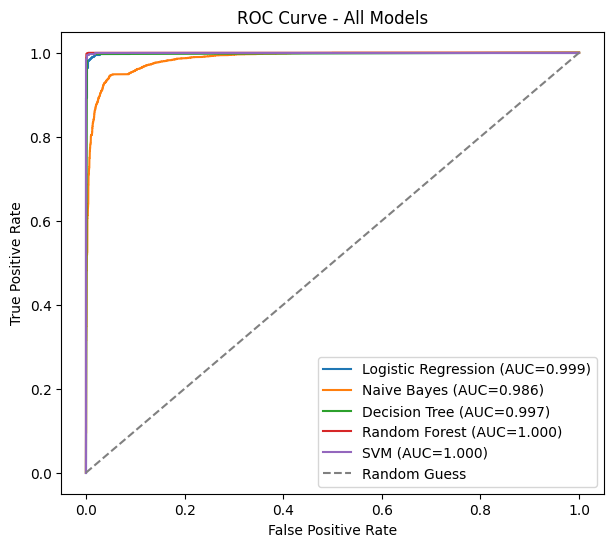

In [ ]:
#roc-auc
from sklearn.metrics import roc_auc_score, roc_curve

models_dict = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

plt.figure(figsize=(7,6))

for name, model in models_dict.items():

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

y_score_svm = svm_model.decision_function(X_test)
auc_svm = roc_auc_score(y_test, y_score_svm)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.show()

In [ ]:
#cross validation by using k fold cross validation
from sklearn.model_selection import cross_val_score

# har model ke liye 5-fold cross-validation
models_to_check = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

for name, model in models_to_check.items():

    # scoring="accuracy" : accuracy metric
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    print(f"{name}:")
    print(f"  Fold-wise scores: {scores}")
    print(f"  Average Accuracy: {scores.mean():.4f}")
    print(f"  Standard Deviation: {scores.std():.4f}")
    print()

Logistic Regression:
  Fold-wise scores: [0.98802864 0.98881181 0.99060192 0.98791676 0.98903435]
  Average Accuracy: 0.9889
  Standard Deviation: 0.0010

Naive Bayes:
  Fold-wise scores: [0.9432759  0.94517789 0.94685612 0.94294026 0.94203872]
  Average Accuracy: 0.9441
  Standard Deviation: 0.0017

Decision Tree:
  Fold-wise scores: [0.99675543 0.99608414 0.9963079  0.99395838 0.9960837 ]
  Average Accuracy: 0.9958
  Standard Deviation: 0.0010

Random Forest:
  Fold-wise scores: [0.99787424 0.99765048 0.99820989 0.99820989 0.9979859 ]
  Average Accuracy: 0.9980
  Standard Deviation: 0.0002

SVM:
  Fold-wise scores: [0.99485343 0.99541284 0.99541284 0.99451779 0.99440528]
  Average Accuracy: 0.9949
  Standard Deviation: 0.0004



In [1]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

#Load + Label + Merge + Shuffle
fake_df = pd.read_csv("Fake.csv", on_bad_lines='skip', engine='python')
real_df = pd.read_csv("True.csv", on_bad_lines='skip', engine='python')
fake_df["label"] = 0
real_df["label"] = 1
df = pd.concat([fake_df, real_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)
df.drop_duplicates(inplace=True)
print("Fake shape:", fake_df.shape, "Real shape:", real_df.shape)


#Preprocessing
df["text"] = df["text"].str.lower()

def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)
df["text"] = df["text"].apply(remove_urls)

def remove_html_tags(text):
    return re.sub(r"<.*?>", "", text)
df["text"] = df["text"].apply(remove_html_tags)

def remove_punctuation(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["text"] = df["text"].apply(remove_punctuation)

def remove_numbers(text):
    return re.sub(r"\d+", "", text)
df["text"] = df["text"].apply(remove_numbers)

stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
df["text"] = df["text"].apply(remove_stopwords)

def tokenize_text(text):
    return word_tokenize(text)
df["tokens"] = df["text"].apply(tokenize_text)

lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]
df["tokens"] = df["tokens"].apply(lemmatize_tokens)

df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))
df["clean_text"] = df["clean_text"].fillna("").astype(str)

print("Preprocessing done! Shape:", df.shape)

# Feature Engineering
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/test split done:", X_train.shape, X_test.shape)

#Train all 5 models
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_predictions))

print("\nAll models trained successfully! Ready for error analysis.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Fake shape: (23481, 5) Real shape: (21417, 5)
Preprocessing done! Shape: (44689, 7)
Train/test split done: (35751, 5000) (8938, 5000)
Logistic Regression Accuracy: 0.9897068695457597
Naive Bayes Accuracy: 0.9426046095323338
Decision Tree Accuracy: 0.996755426269859
Random Forest Accuracy: 0.9984336540613112
SVM Accuracy: 0.9956366077422242

All models trained successfully! Ready for error analysis.


In [2]:
wrong_predictions_mask = (rf_predictions != y_test.values)
wrong_indices = y_test.index[wrong_predictions_mask]
wrong_examples = df.loc[wrong_indices, ["clean_text", "label"]].copy()
wrong_examples["predicted"] = rf_predictions[wrong_predictions_mask]

pd.set_option('display.max_colwidth', 150)
print(wrong_examples)

                                                                                                                                                  clean_text  \
36796  difference make well make lot difference irs clinton charity got called carpet misfiling tax return year old oops hillary clinton family charity r...   
20359  believe un headquarters would make great condo building please see krauthammer video start trump administration decided significantly reduce un bu...   
3151   lawless president finally conceded even save head clinton crime syndicate oh well lucky hillary orange new black president barack obama meet democ...   
23648  michigan court appeal rejected green party candidate jill stein request recount presidential ballot michigan court ruled board state canvasser all...   
1284   lawless president finally conceded even save head clinton crime syndicate oh well lucky hillary orange new black president barack obama meet democ...   
22097  reuters highlight reuters intervi

In [6]:
print("Total wrong predictions:", len(wrong_examples))
print(wrong_examples[["label", "predicted"]])

Total wrong predictions: 14
       label  predicted
36796      0          1
20359      0          1
3151       0          1
23648      0          1
1284       0          1
22097      1          0
33142      1          0
26097      1          0
3605       1          0
11711      1          0
29643      0          1
31358      1          0
13018      0          1
20481      0          1


In [8]:
available_indices = [idx for idx in [48141, 29871] if idx in df.index]

duplicate_check = df.loc[
    available_indices,
    ["title", "text", "clean_text", "label"]
]

pd.set_option('display.max_colwidth', 300)

print(duplicate_check)

                                                            title  \
29871   SNL Parodies All-White Oscars In Brutal Smackdown (VIDEO)   

                                                                                                                                                                                                                                                                                                              text  \
29871  last night saturday night live delivered brutal blow hollywood diversity issues calling academy awards overlooking minority actors favor white nominees academy diversity problem came light nominees announced th annual academy awards revealing black actors nominated individual acting categories l...   

                                                                                                                                                                                                                                                

In [9]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 30]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters found: {'max_depth': None, 'n_estimators': 100}
Best cross-validation accuracy: 0.9976504153729966


In [10]:
#models save
import joblib

# trained Random Forest model save
joblib.dump(rf_model, "fake_news_model.pkl")

# TF-IDF vectorizer also save
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model aur vectorizer successfully saved!")

Model aur vectorizer successfully saved!
